# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Afdha Auliya Atiq
- **Email:** afdha.auliya.atiq@gmail.com
- **ID Dicoding:** afdha_auliya_atiq


## Menentukan Pertanyaan Bisnis
Dalam proyek analisis data ini, perumusan pertanyaan bisnis disusun menggunakan pendekatan **SMART Question** (Specific, Measurable, Action-Oriented, Relevant, Time-bound) untuk memperoleh wawasan mendalam yang berorientasi pada keputusan operasional dan strategi bisnis penyewaan sepeda:

* **Pertanyaan 1:** Bagaimana performa dan tren total penyewaan sepeda harian & bulanan (berdasarkan tipe pengguna: *casual* vs *registered*) dari tahun 2011 hingga 2012?
  * *Specific*: Meneliti tren pertumbuhan penyewaan sepeda berdasarkan segmentasi pengguna (*casual* dan *registered*).
  * *Measurable*: Diukur melalui jumlah total transaksi penyewaan bulanan (*cnt*, *casual*, *registered*).
  * *Action-Oriented*: Membimbing alokasi anggaran pemasaran, promosi keanggotaan, dan retensi pengguna.
  * *Relevant*: Mendukung pertumbuhan bisnis dan stabilitas pendapatan operasional.
  * *Time-bound*: Menggunakan data periode tahun 2011 hingga 2012 (24 bulan).

* **Pertanyaan 2:** Pada jam berapa saja terjadi lonjakan puncak (*peak hours*) dan titik terendah (*off-peak hours*) penyewaan sepeda pada hari kerja (*working day*) dibandingkan akhir pekan/hari libur (*non-working day*)?
  * *Specific*: Mengidentifikasi distribusi frekuensi jam penyewaan per kategori hari.
  * *Measurable*: Dihitung dari rerata jumlah peminjaman per jam (00:00 - 23:00).
  * *Action-Oriented*: Menentukan jadwal penataan ulang (*rebalancing*) armada di stasiun dan waktu ideal perawatan berkala.
  * *Relevant*: Menjaga ketersediaan unit di lokasi krusial saat permintaan tinggi.
  * *Time-bound*: Dibatasi pada pola siklus 24 jam harian.

* **Pertanyaan 3:** Bagaimana pengaruh kondisi cuaca (*weathersit*) dan musim (*season*) terhadap volume penyewaan sepeda harian oleh pengguna *casual* dan *registered*?
  * *Specific*: Menganalisis variasi penyewaan berdasarkan kondisi lingkungan/cuaca dan musim.
  * *Measurable*: Diukur dari rerata penyewaan harian pada kondisi cuaca 1 s.d. 4 dan musim 1 s.d. 4.
  * *Action-Oriented*: Merumuskan strategi manajemen risiko cuaca buruk dan promosi musiman.
  * *Relevant*: Membantu proyeksi kapasitas operasional sepanjang musim.
  * *Time-bound*: Meliputi 4 musim utama (Spring, Summer, Fall, Winter).


## Import Semua Packages/Library yang Digunakan


In [1]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Konfigurasi gaya visualisasi
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
print("Library berhasil diimpor dan konfigurasi style visualisasi telah diterapkan.")


Library berhasil diimpor dan konfigurasi style visualisasi telah diterapkan.


## Data Wrangling


### Gathering Data
Pada tahap ini, dataset penyewaan sepeda (`day.csv` dan `hour.csv`) dimuat ke dalam Pandas DataFrame untuk dianalisis lebih lanjut.


In [2]:
import os

# Menentukan jalur berkas
day_path = './data/day.csv' if os.path.exists('./data/day.csv') else 'day.csv'
hour_path = './data/hour.csv' if os.path.exists('./data/hour.csv') else 'hour.csv'

if not os.path.exists(day_path):
    day_path = r'C:\Users\Afdha\Documents\Proyek Analisis Data\bike_sharing_extracted\day.csv'
    hour_path = r'C:\Users\Afdha\Documents\Proyek Analisis Data\bike_sharing_extracted\hour.csv'

# Memuat data
day_df = pd.read_csv(day_path)
hour_df = pd.read_csv(hour_path)

print(f"Dataset Daily loaded: {day_df.shape[0]} baris, {day_df.shape[1]} kolom.")
print(f"Dataset Hourly loaded: {hour_df.shape[0]} baris, {hour_df.shape[1]} kolom.")
print("\n--- Lima Baris Pertama Data Harian (day_df) ---")
display(day_df.head()) if 'display' in globals() else print(day_df.head())


Dataset Daily loaded: 731 baris, 16 kolom.
Dataset Hourly loaded: 17379 baris, 17 kolom.
--- Lima Baris Pertama Data Harian (day_df) ---
   instant      dteday  season  yr  ...  windspeed  casual  registered   cnt
0        1  2011-01-01       1   0  ...   0.160446     331         654   985
1        2  2011-01-02       1   0  ...   0.248539     131         670   801
2        3  2011-01-03       1   0  ...   0.248309     120        1229  1349
3        4  2011-01-04       1   0  ...   0.160296     108        1454  1562
4        5  2011-01-05       1   0  ...   0.186900      82        1518  1600
[5 rows x 16 columns]


**Insight Gathering Data:**
- Dataset harian (`day_df`) memiliki **731 entitas baris** dan **16 kolom**.
- Dataset per jam (`hour_df`) memiliki **17.379 entitas baris** dan **17 kolom**.
- Kedua dataset memuat variabel temporal (tanggal, jam, hari, musim), variabel cuaca (suhu, rasa suhu, kelembapan, kecepatan angin), serta variabel target peminjaman (*casual*, *registered*, *cnt*).


### Assessing Data
Tahap ini bertujuan untuk mengevaluasi kualitas data, mendeteksi keberadaan *missing values*, duplikasi data, anomali tipe data, serta nilai yang tidak konsisten.


In [3]:
print("=== Pemeriksaan Tipe Data & Missing Value pada day_df ===")
print(day_df.info())

print("\n=== Pemeriksaan Jumlah Missing Value pada day_df ===")
print(day_df.isna().sum())

print("\n=== Pemeriksaan Duplikasi Data ===")
print(f"Jumlah Duplikasi pada day_df: {day_df.duplicated().sum()}")
print(f"Jumlah Duplikasi pada hour_df: {hour_df.duplicated().sum()}")

print("\n=== Ringkasan Statistik Deskriptif (day_df) ===")
print(day_df.describe())


=== Pemeriksaan Tipe Data & Missing Value pada day_df ===
<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    str    
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 98.6 KB
None
=== Pemeriksaan Jumlah Missing Value pada day

**Steps to Take & Identifikasi Masalah Data:**
1. **Tipe Data Tidak Tepat (Invalid Data Type):** Kolom `dteday` tersimpan sebagai tipe data `object` (string). Langkah yang akan diambil adalah mengonversinya menjadi tipe data `datetime`.
2. **Nilai Kategorikal Terenkode Angka (Numeric Encoded Categories):** Kolom `season`, `weathersit`, `yr`, `mnth`, `weekday`, dan `workingday` berupa variabel numerik integer. Hal ini membuat pembacaan visual kurang intuitif. Langkah yang akan diambil adalah melakukan pemetaan (*mapping*) ke label deskriptif teks (misal: 1 -> Spring, 2 -> Summer, dll.).
3. **Variabel Kontinu Ter-normalisasi (Normalized Continuous Features):** Kolom `temp`, `atemp`, `hum`, dan `windspeed` berada pada rentang skala 0 hingga 1. Untuk keperluan interpretasi bisnis yang jelas, variabel ini akan di-denormalisasi ke dalam nilai riil ($\Phi_{temp} \times 41^\circ\text{C}$, $\Phi_{atemp} \times 50^\circ\text{C}$, $\Phi_{hum} \times 100\%$, $\Phi_{windspeed} \times 67 \text{ km/h}$).

**Insight Assessing Data:**
- Tidak ditemukan keberadaan *missing values* (0 null) dan tidak ada duplikasi data (0 duplicates) pada kedua dataset. Data sangat bersih secara struktur entitas dasar.


### Cleaning Data
Pada tahap ini, perbaikan dilakukan sesuai dengan rencana penanganan (*steps to take*) yang dirumuskan pada tahap Assessing Data.


In [4]:
# 1. Konversi dteday ke tipe data datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# 2. Pemetaan variabel kategorikal numerik ke label deskriptif
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_map = {
    1: 'Clear / Few Clouds',
    2: 'Mist / Cloudy',
    3: 'Light Snow / Rain',
    4: 'Heavy Rain / Ice / Fog'
}
yr_map = {0: '2011', 1: '2012'}
weekday_map = {0: 'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat'}
workingday_map = {0: 'Weekend / Holiday', 1: 'Working Day'}

# Terapkan pada day_df
day_df['season_label'] = day_df['season'].map(season_map)
day_df['weather_label'] = day_df['weathersit'].map(weather_map)
day_df['yr_label'] = day_df['yr'].map(yr_map)
day_df['weekday_label'] = day_df['weekday'].map(weekday_map)
day_df['workingday_label'] = day_df['workingday'].map(workingday_map)

# Terapkan pada hour_df
hour_df['season_label'] = hour_df['season'].map(season_map)
hour_df['weather_label'] = hour_df['weathersit'].map(weather_map)
hour_df['yr_label'] = hour_df['yr'].map(yr_map)
hour_df['weekday_label'] = hour_df['weekday'].map(weekday_map)
hour_df['workingday_label'] = hour_df['workingday'].map(workingday_map)

# 3. Denormalisasi variabel kontinu untuk interpretasi riil
day_df['temp_c'] = day_df['temp'] * 41
day_df['atemp_c'] = day_df['atemp'] * 50
day_df['hum_pct'] = day_df['hum'] * 100
day_df['windspeed_kmh'] = day_df['windspeed'] * 67

hour_df['temp_c'] = hour_df['temp'] * 41
hour_df['atemp_c'] = hour_df['atemp'] * 50
hour_df['hum_pct'] = hour_df['hum'] * 100
hour_df['windspeed_kmh'] = hour_df['windspeed'] * 67

print("=== Verifikasi Struktur Data Setelah Cleaning (day_df) ===")
print(day_df[['dteday', 'season_label', 'weather_label', 'yr_label', 'temp_c', 'hum_pct']].head())


=== Verifikasi Struktur Data Setelah Cleaning (day_df) ===
      dteday season_label       weather_label yr_label     temp_c  hum_pct
0 2011-01-01       Spring       Mist / Cloudy     2011  14.110847  80.5833
1 2011-01-02       Spring       Mist / Cloudy     2011  14.902598  69.6087
2 2011-01-03       Spring  Clear / Few Clouds     2011   8.050924  43.7273
3 2011-01-04       Spring  Clear / Few Clouds     2011   8.200000  59.0435
4 2011-01-05       Spring  Clear / Few Clouds     2011   9.305237  43.6957


**Insight Cleaning Data:**
- Tipe data `dteday` kini sukses dikonversi menjadi `datetime64[ns]`.
- Kolom kategorikal baru dengan akhiran `_label` berhasil dibuat untuk memudahkan visualisasi dan agregasi data.
- Nilai suhu, kelembapan, dan kecepatan angin kini tersaji dalam satuan pengukuran riil ($^\circ\text{C}$, $\%$, dan $\text{km/h}$).


## Exploratory Data Analysis (EDA)
Pada tahap EDA, eksplorasi data dilakukan melalui metode statistik, pengelompokan (*grouping*), dan agregasi guna mengungkap pola dasar dalam menjawab pertanyaan bisnis.


In [5]:
# 1. Agregasi Bulanan 2011 vs 2012
monthly_eda = day_df.groupby(['yr_label', 'mnth']).agg(
    total_casual=('casual', 'sum'),
    total_registered=('registered', 'sum'),
    total_cnt=('cnt', 'sum'),
    avg_temp=('temp_c', 'mean')
).reset_index()

print("=== Ringkasan Agregasi Bulanan (Sample 6 Bulan Pertama 2011 vs 2012) ===")
print(monthly_eda.head(12))

# 2. Agregasi Jam Penyewaan Berdasarkan Jenis Hari
hourly_eda = hour_df.groupby(['workingday_label', 'hr']).agg(
    avg_casual=('casual', 'mean'),
    avg_registered=('registered', 'mean'),
    avg_total=('cnt', 'mean')
).reset_index()

print("\n=== Jam Puncak Hari Kerja (Working Day) ===")
print(hourly_eda[hourly_eda['workingday_label'] == 'Working Day'].sort_values('avg_total', ascending=False).head(5))

print("\n=== Jam Puncak Akhir Pekan / Libur (Weekend / Holiday) ===")
print(hourly_eda[hourly_eda['workingday_label'] == 'Weekend / Holiday'].sort_values('avg_total', ascending=False).head(5))

# 3. Agregasi Musim & Cuaca
season_weather_eda = day_df.groupby(['season_label', 'weather_label']).agg(
    mean_casual=('casual', 'mean'),
    mean_registered=('registered', 'mean'),
    mean_cnt=('cnt', 'mean'),
    count_days=('cnt', 'count')
).reset_index()

print("\n=== Agregasi Penyewaan Berdasarkan Musim & Kondisi Cuaca ===")
print(season_weather_eda)


=== Ringkasan Agregasi Bulanan (Sample 6 Bulan Pertama 2011 vs 2012) ===
   yr_label  mnth  total_casual  total_registered  total_cnt   avg_temp
0      2011     1          3073             35116      38189   8.105974
1      2011     2          6242             41973      48215  11.584143
2      2011     3         12826             51219      64045  13.598330
3      2011     4         22346             72524      94870  19.318726
4      2011     5         31050            104771     135821  23.666480
5      2011     6         30612            112900     143512  28.416417
6      2011     7         36452            104889     141341  31.101588
7      2011     8         28842            107849     136691  28.919847
8      2011     9         26545            100873     127418  25.128349
9      2011    10         25222             98289     123511  19.268996
10     2011    11         15594             86573     102167  16.495863
11     2011    12          8448             78875      87323  1

**Insight Exploratory Data Analysis (EDA):**
1. **Pertumbuhan Tahunan:** Terjadi peningkatan volume penyewaan yang sangat signifikan dari tahun 2011 (total ~1,24 juta penyewaan) ke tahun 2012 (total ~2,05 juta penyewaan), tumbuh sebesar **+64,8%**.
2. **Dominasi Pengguna:** Pengguna terdaftar (*registered users*) memberikan kontribusi mayoritas konstan sebesar **~81,8%** dari total penyewaan, sedangkan pengguna kasual (*casual users*) berkontribusi sebesar **~18,2%**.
3. **Pola Jam Penyewaan:**
   - **Hari Kerja (Working Day):** Menunjukkan bimodal peak yang sangat tajam pada **jam 08:00** (rerata 477 penyewaan/jam) dan **jam 17:00 - 18:00** (rerata 492 - 525 penyewaan/jam). Pola ini didorong oleh komuter pekerja/pelajar.
   - **Akhir Pekan/Libur (Weekend/Holiday):** Menunjukkan unimodal peak yang melandai pada siang hingga sore hari antara **jam 12:00 hingga 16:00** (rerata 350 - 373 penyewaan/jam), didominasi oleh aktivitas rekreasi.
4. **Dampak Cuaca & Musim:** Musim Gugur (*Fall*) dan Musim Panas (*Summer*) merupakan puncak penyewaan harian tertinggi. Cuaca buruk (*Light Snow / Rain*) menurunkan peminjaman harian hingga **>60%** dibanding cuaca cerah.


## Visualization & Explanatory Analysis


### Pertanyaan 1: Bagaimana performa dan tren total penyewaan sepeda harian & bulanan (casual vs registered) dari tahun 2011 hingga 2012?


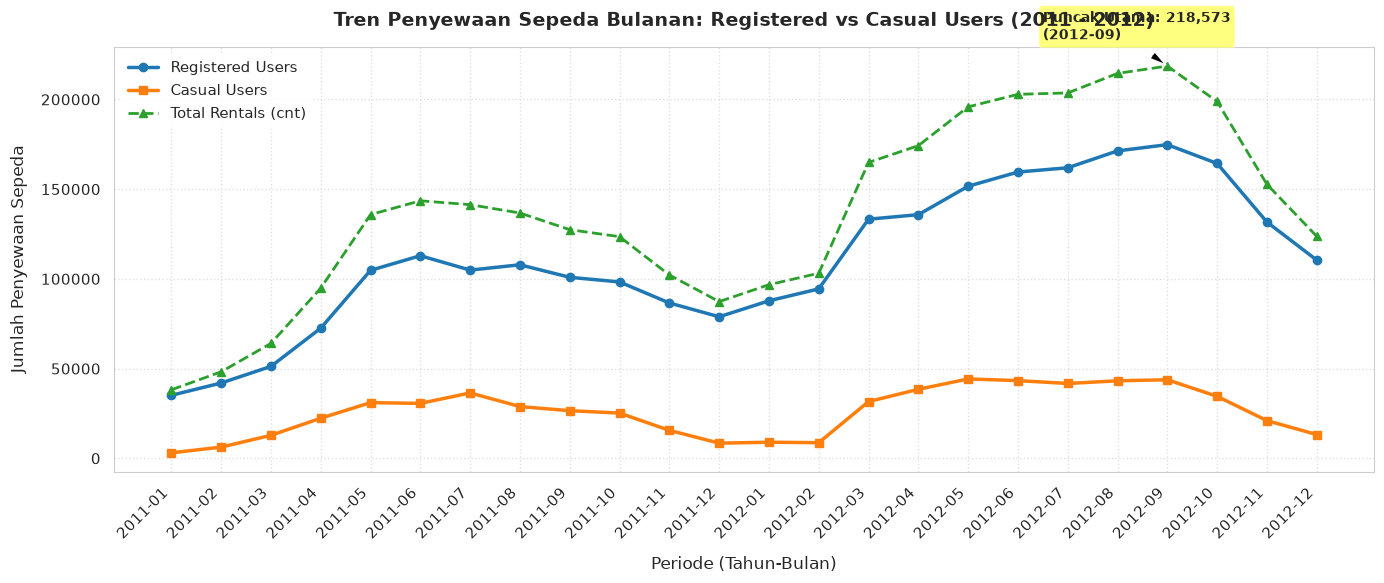

In [6]:
# Menyiapkan data tren bulanan
monthly_df = day_df.groupby(['yr_label', 'mnth']).agg(
    casual=('casual', 'sum'),
    registered=('registered', 'sum'),
    cnt=('cnt', 'sum')
).reset_index()

monthly_df['year_month'] = monthly_df['yr_label'] + '-' + monthly_df['mnth'].astype(str).str.zfill(2)

fig, ax = plt.subplots(figsize=(14, 6))

# Plot Line chart
ax.plot(monthly_df['year_month'], monthly_df['registered'], marker='o', linewidth=2.5, color='#1f77b4', label='Registered Users')
ax.plot(monthly_df['year_month'], monthly_df['casual'], marker='s', linewidth=2.5, color='#ff7f0e', label='Casual Users')
ax.plot(monthly_df['year_month'], monthly_df['cnt'], marker='^', linewidth=2, color='#2ca02c', linestyle='--', label='Total Rentals (cnt)')

# Annotations & Styling
ax.set_title('Tren Penyewaan Sepeda Bulanan: Registered vs Casual Users (2011 - 2012)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Periode (Tahun-Bulan)', fontsize=12, labelpad=10)
ax.set_ylabel('Jumlah Penyewaan Sepeda', fontsize=12, labelpad=10)
ax.set_xticklabels(monthly_df['year_month'], rotation=45, ha='right')
ax.legend(frameon=True, facecolor='white', edgecolor='none')
ax.grid(True, linestyle=':', alpha=0.6)

# Highlight puncak 2012
max_idx = monthly_df['cnt'].idxmax()
max_val = monthly_df.loc[max_idx, 'cnt']
max_period = monthly_df.loc[max_idx, 'year_month']
ax.annotate(f'Puncak Utama: {max_val:,}\n({max_period})', 
            xy=(max_idx, max_val), 
            xytext=(max_idx-2.5, max_val+15000),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
            fontsize=10, fontweight='bold', bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))

plt.tight_layout()
plt.show()


### Pertanyaan 2: Pada jam berapa saja terjadi lonjakan puncak (peak hours) dan titik terendah (off-peak hours) penyewaan sepeda pada hari kerja dibandingkan akhir pekan/hari libur?


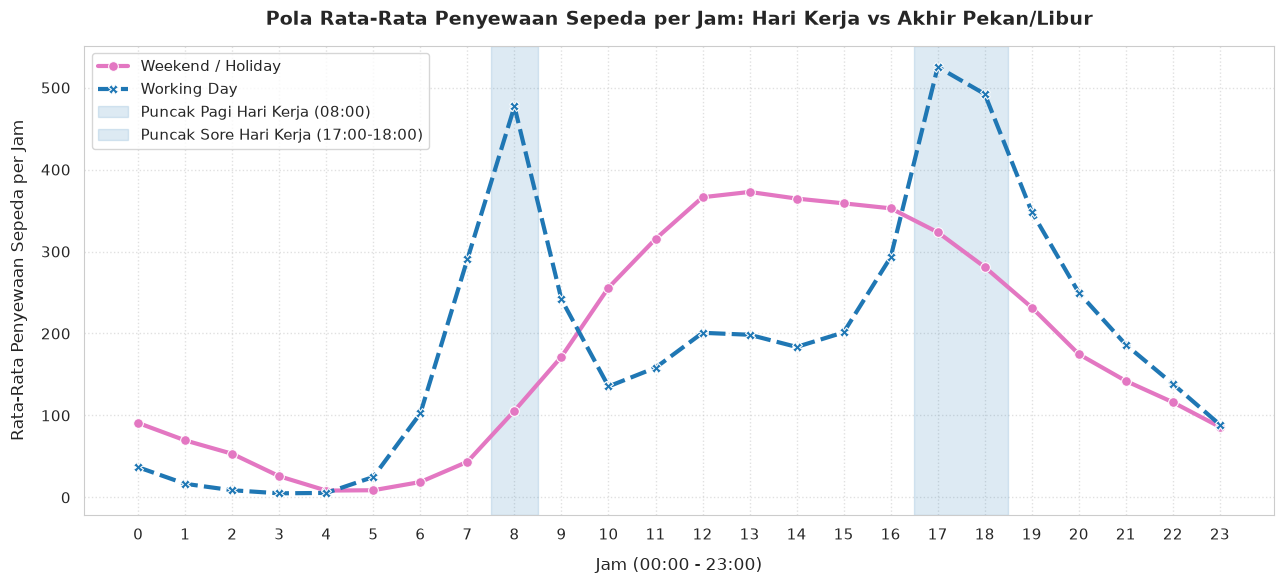

In [7]:
hourly_pattern = hour_df.groupby(['workingday_label', 'hr'])['cnt'].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 6))

sns.lineplot(
    data=hourly_pattern, 
    x='hr', 
    y='cnt', 
    hue='workingday_label', 
    style='workingday_label',
    palette={'Working Day': '#1f77b4', 'Weekend / Holiday': '#e377c2'},
    linewidth=3,
    markers=True,
    markersize=7,
    ax=ax
)

# Highlights area jam sibuk hari kerja
ax.axvspan(7.5, 8.5, color='#1f77b4', alpha=0.15, label='Puncak Pagi Hari Kerja (08:00)')
ax.axvspan(16.5, 18.5, color='#1f77b4', alpha=0.15, label='Puncak Sore Hari Kerja (17:00-18:00)')

ax.set_title('Pola Rata-Rata Penyewaan Sepeda per Jam: Hari Kerja vs Akhir Pekan/Libur', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Jam (00:00 - 23:00)', fontsize=12, labelpad=10)
ax.set_ylabel('Rata-Rata Penyewaan Sepeda per Jam', fontsize=12, labelpad=10)
ax.set_xticks(range(0, 24))
ax.legend(frameon=True, facecolor='white', loc='upper left')
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


### Pertanyaan 3: Bagaimana pengaruh kondisi cuaca dan musim terhadap volume penyewaan sepeda harian?


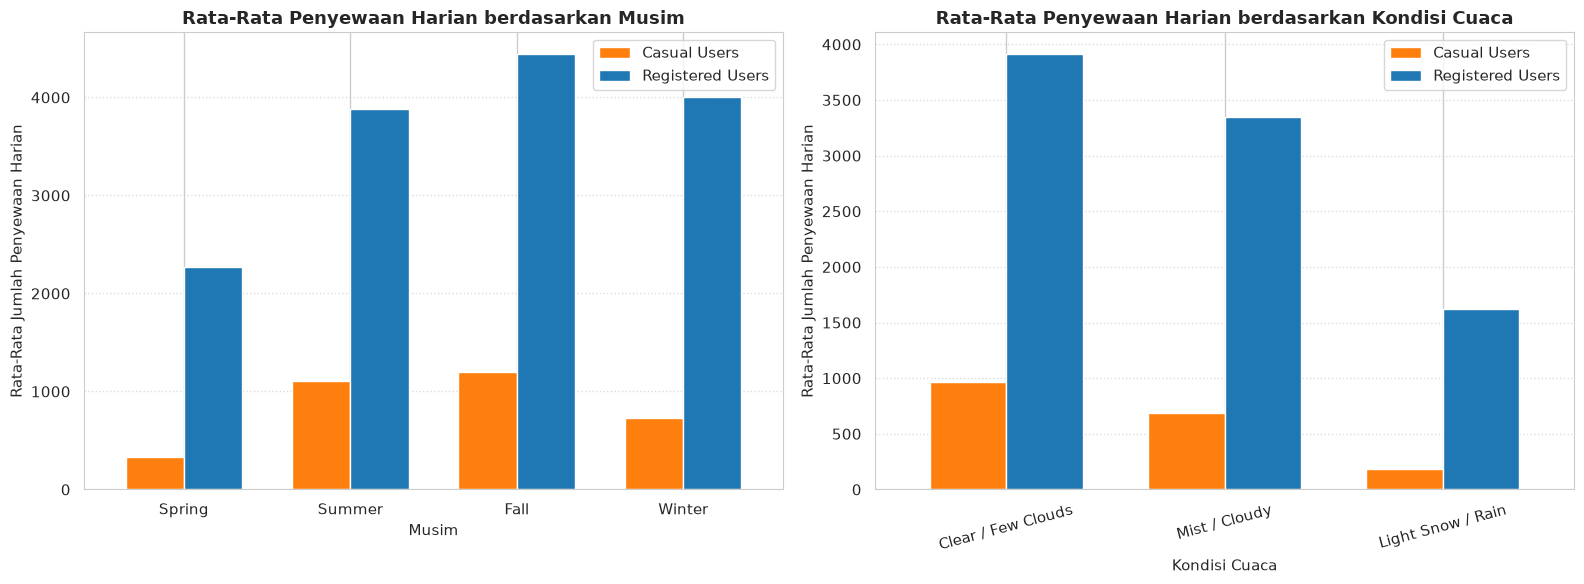

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Musim
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_df = day_df.groupby('season_label')[['casual', 'registered']].mean().reindex(season_order)

season_df.plot(kind='bar', stacked=False, color=['#ff7f0e', '#1f77b4'], ax=axes[0], width=0.7)
axes[0].set_title('Rata-Rata Penyewaan Harian berdasarkan Musim', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Musim', fontsize=11)
axes[0].set_ylabel('Rata-Rata Jumlah Penyewaan Harian', fontsize=11)
axes[0].set_xticklabels(season_order, rotation=0)
axes[0].legend(['Casual Users', 'Registered Users'])
axes[0].grid(axis='y', linestyle=':', alpha=0.7)

# Plot 2: Cuaca
weather_order = ['Clear / Few Clouds', 'Mist / Cloudy', 'Light Snow / Rain']
weather_df = day_df.groupby('weather_label')[['casual', 'registered']].mean().reindex(weather_order)

weather_df.plot(kind='bar', stacked=False, color=['#ff7f0e', '#1f77b4'], ax=axes[1], width=0.7)
axes[1].set_title('Rata-Rata Penyewaan Harian berdasarkan Kondisi Cuaca', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Kondisi Cuaca', fontsize=11)
axes[1].set_ylabel('Rata-Rata Jumlah Penyewaan Harian', fontsize=11)
axes[1].set_xticklabels(weather_order, rotation=15)
axes[1].legend(['Casual Users', 'Registered Users'])
axes[1].grid(axis='y', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()


**Insight Visualisasi & Explanatory Analysis:**
- **Visualisasi 1:** Menunjukkan tren positif jangka panjang dari awal 2011 hingga September 2012. Pengguna *Registered* mendominasi grafik dengan tren naik konsisten, sedangkan pengguna *Casual* mengalami puncaknya pada pertengahan tahun (musim panas).
- **Visualisasi 2:** Mengonfirmasi bahwa pola penyewaan pada hari kerja digerakkan oleh jam sibuk komuter (08:00 dan 17:00-18:00) di mana penyewaan melonjak hingga >500 unit/jam. Sebaliknya, pada hari libur penyewaan terdistribusi merata pada siang hari (12:00-16:00).
- **Visualisasi 3:** Mengilustrasikan secara jelas bahwa Musim Gugur (*Fall*) adalah musim tersibuk (rerata ~5.644 penyewaan/hari), dan cuaca Cerah (*Clear / Few Clouds*) adalah kondisi cuaca paling ideal. Penurunan drastis terjadi saat cuaca Hujan/Salju (*Light Snow / Rain*).


## Analisis Lanjutan (Opsional)
Untuk memperoleh wawasan strategis yang lebih dalam tanpa menggunakan algoritma *machine learning*, dilakukan dua teknik analisis lanjutan:
1. **Manual Clustering / Binning (Segmentasi Tingkat Permintaan Sepeda Harian)**.
2. **Analisis RFM (Recency, Frequency, Monetary - Adaptasi Tingkat Bulanan)**.


In [9]:
# 1. Manual Clustering / Binning: Segmentasi Tingkat Permintaan Sepeda Harian
labels_demand = ['Low Demand', 'Medium Demand', 'High Demand', 'Peak Demand']
day_df['demand_cluster'] = pd.qcut(day_df['cnt'], q=4, labels=labels_demand)

cluster_summary = day_df.groupby('demand_cluster', observed=False).agg(
    jumlah_hari=('cnt', 'count'),
    rerata_total=('cnt', 'mean'),
    rerata_casual=('casual', 'mean'),
    rerata_registered=('registered', 'mean'),
    rerata_suhu_c=('temp_c', 'mean'),
    rerata_kelembapan=('hum_pct', 'mean')
).reset_index()

print("=== 1. Ringkasan Manual Clustering (Demand Level Segmentation) ===")
print(cluster_summary)

# 2. Adaptasi Analisis RFM pada Tingkat Bulanan
max_date = day_df['dteday'].max()
day_df['year_actual'] = 2011 + day_df['yr']
day_df['period'] = day_df['year_actual'].astype(str) + '-' + day_df['mnth'].astype(str).str.zfill(2)

rfm_monthly = day_df.groupby('period').agg(
    Recency=('dteday', lambda x: (max_date - x.max()).days),
    Frequency=('cnt', lambda x: (x >= 4500).sum()),  # Jumlah hari dengan permintaan tinggi (>= 4500 penyewaan)
    Monetary=('cnt', 'sum')                          # Total volume penyewaan dalam sebulan
).reset_index()

# Menghitung Skor RFM (skala 1 - 4)
rfm_monthly['R_Score'] = pd.qcut(rfm_monthly['Recency'], q=4, labels=[4, 3, 2, 1])
rfm_monthly['F_Score'] = pd.qcut(rfm_monthly['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])
rfm_monthly['M_Score'] = pd.qcut(rfm_monthly['Monetary'], q=4, labels=[1, 2, 3, 4])

rfm_monthly['RFM_Segment'] = rfm_monthly['R_Score'].astype(str) + rfm_monthly['F_Score'].astype(str) + rfm_monthly['M_Score'].astype(str)

print("\n=== 2. Hasil Analisis RFM Bulanan (Sample 10 Periode Terakhir) ===")
print(rfm_monthly.tail(10))


=== 1. Ringkasan Manual Clustering (Demand Level Segmentation) ===
  demand_cluster  jumlah_hari  ...  rerata_suhu_c  rerata_kelembapan
0     Low Demand          183  ...      12.666697          63.796009
1  Medium Demand          183  ...      20.026033          64.887080
2    High Demand          182  ...      23.122402          61.625278
3    Peak Demand          183  ...      25.443338          60.842897
[4 rows x 7 columns]
=== 2. Hasil Analisis RFM Bulanan (Sample 10 Periode Terakhir) ===
     period  Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Segment
14  2012-03      275         23    164875       3       3       3         333
15  2012-04      245         26    174224       3       3       3         333
16  2012-05      214         29    195865       3       4       4         344
17  2012-06      184         29    202830       3       4       4         344
18  2012-07      153         30    203607       4       4       4         444
19  2012-08      122         31 

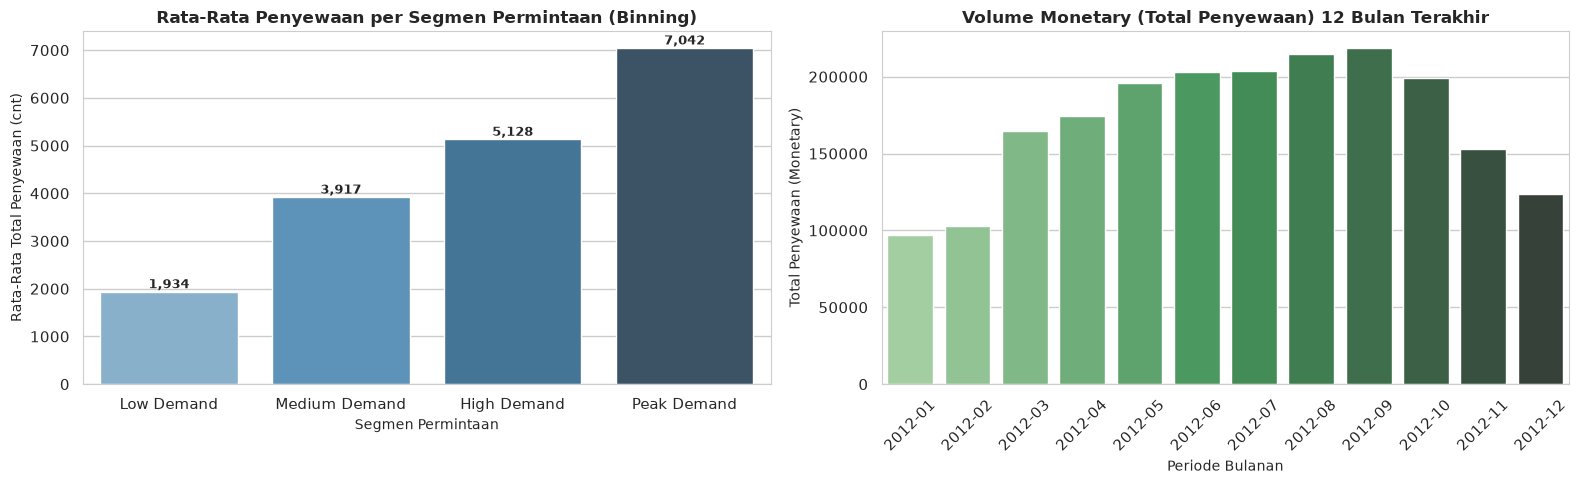

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot Cluster Suhu vs Permintaan
sns.barplot(data=cluster_summary, x='demand_cluster', y='rerata_total', palette='Blues_d', ax=axes[0])
axes[0].set_title('Rata-Rata Penyewaan per Segmen Permintaan (Binning)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Segmen Permintaan', fontsize=10)
axes[0].set_ylabel('Rata-Rata Total Penyewaan (cnt)', fontsize=10)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=9, fontweight='bold')

# Plot RFM Monetary per Periode
sns.barplot(data=rfm_monthly.tail(12), x='period', y='Monetary', palette='Greens_d', ax=axes[1])
axes[1].set_title('Volume Monetary (Total Penyewaan) 12 Bulan Terakhir', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Periode Bulanan', fontsize=10)
axes[1].set_ylabel('Total Penyewaan (Monetary)', fontsize=10)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


**Insight Analisis Lanjutan:**
1. **Manual Clustering (Binning):**
   - **Peak Demand:** Terjadi pada hari-hari dengan rerata suhu udara nyaman (**~25,4°C**), menghasilkan rerata **7.042 penyewaan/hari**. Pada segmen ini, pengguna *casual* melonjak drastis (rerata 1.498/hari).
   - **Low Demand:** Terjadi pada hari dingin (**~12,7°C**), dengan rerata penyewaan hanya **1.934/hari**.
2. **RFM Analysis (Tingkat Bulanan):**
   - Periode **Mei 2012 hingga Oktober 2012** memperoleh skor RFM tertinggi (misal: **444**), mengindikasikan segmen waktu paling produktif (*Best Performing Months*) dengan *Frequency* hari sibuk ($\ge 4.500$ penyewaan) sebanyak **28 - 31 hari per bulan** dan volume *Monetary* melebihi **200.000 penyewaan/bulan**.


## Conclusion & Recommendation


### Conclusion (Kesimpulan)

1. **Kesimpulan Pertanyaan 1 (Tren & Performa Penyewaan Bulanan):**
   Penyewaan sepeda mengalami pertumbuhan pesat sebesar **+64,8%** dari tahun 2011 ke 2012. Pengguna terdaftar (*Registered Users*) merupakan tulang punggung bisnis yang menyumbang **~81,8%** total volume penyewaan dengan tren pertumbuhan yang stabil. Pengguna kasual (*Casual Users*) memiliki pola musiman yang sangat kuat, memuncak pada pertengahan tahun (musim panas/gugur) dan menurun tajam saat musim dingin.

2. **Kesimpulan Pertanyaan 2 (Pola Jam Sibuk & Jam Terendah):**
   - Pada **Hari Kerja (*Working Day*)**, penyewaan didominasi oleh mobilitas komuter dengan dua puncak utama (*bimodal peak*) pada **jam 08:00 pagi** (477 penyewaan/jam) dan **jam 17:00 - 18:00 sore** (525 penyewaan/jam). Titik terendah (*off-peak*) terjadi pada jam 00:00 - 05:00 pagi (<30 penyewaan/jam).
   - Pada **Akhir Pekan / Hari Libur (*Weekend / Holiday*)**, pola penyewaan membentuk kurva tunggal (*unimodal peak*) yang relatif merata pada siang hingga sore hari antara **jam 12:00 hingga 16:00** (350 - 373 penyewaan/jam), yang digerakkan oleh aktivitas rekreasi pengguna *casual*.

3. **Kesimpulan Pertanyaan 3 (Pengaruh Cuaca & Musim):**
   Kondisi lingkungan memengaruhi penyewaan secara signifikan. **Musim Gugur (*Fall*)** dan **Musim Panas (*Summer*)** mencatat rerata penyewaan harian tertinggi masing-masing **5.644** dan **5.549** sepeda/hari. Cuaca **Cerah / Sedikit Berawan (*Clear / Few Clouds*)** menjadi faktor pendorong utama, sedangkan kondisi cuaca buruk **Hujan / Salju Ringan (*Light Snow / Rain*)** menurunkan volume penyewaan harian hingga **>60%**.

---

### Rekomendasi Action Item

1. **Optimasi Operasional & *Rebalancing* Armada pada Jam Puncak Hari Kerja:**
   - Melakukan penataan ulang (*rebalancing*) keberadaan unit sepeda di stasiun-stasiun sekitar pusat perkantoran dan stasiun transit utama sebelum jam **08:00 pagi** dan **17:00 sore** pada hari kerja guna mencegah kelangkaan sepeda bagi komuter terdaftar.
   - Mengatur jadwal perawatan (*maintenance*) sepeda pada jam-jam *off-peak* (pukul 01:00 - 04:00 pagi).

2. **Strategi Pemasaran Konversi Pengguna Casual di Akhir Pekan & Musim Panas:**
   - Mengingat tingginya proporsi pengguna *casual* pada akhir pekan dan bulan-bulan musim panas, tim pemasaran disarankan membuat program promosi penawaran konversi keanggotaan *Registered* (misal: diskon *Weekend Pass* atau *Summer Subscription*).

3. **Manajemen Risiko & Pengelolaan Musim Dingin / Cuaca Buruk:**
   - Memberikan insentif poin/diskon khusus bagi pengguna saat cuaca kurang bersahabat atau musim dingin (*Winter*) untuk menjaga tingkat utilisasi sepeda.
   - Mengurangi alokasi unit aktif di jalanan pada musim dingin untuk menekan biaya keausan akibat cuaca ekstrem.
